# Arabic Character Image Generation Using Diffusion Models

### Step 1: Source the dataset

In [ ]:
# 1) Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Download and Extract HMBD Dataset from Kaggle

This step automates the retrieval of the **HMBD v1 Arabic handwritten characters dataset**:

- Sets up Kaggle API credentials.
- Authenticates with Kaggle.
- Downloads and unzips the dataset (`hossammbalaha/hmbd-v1-arabic-handwritten-characters-dataset`) into the local `HMBD_v1/` directory.
- Optionally verifies the download by printing file counts.

**Purpose:** To ensure the required OCR dataset is available locally for further processing and training.

In [ ]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import zipfile

# ─── 1) Configure your Kaggle credentials in-process ──────────────────────────────
os.environ['KAGGLE_USERNAME'] = ''       # replace with your username
os.environ['KAGGLE_KEY']      = ''  # your API key

# ─── 2) Authenticate to Kaggle ───────────────────────────────────────────────────
api = KaggleApi()
api.authenticate()  # raises if creds are invalid :contentReference[oaicite:0]{index=0}

# ─── 3) Download the dataset ZIP and auto-unzip ──────────────────────────────────
dataset_slug = 'hossammbalaha/hmbd-v1-arabic-handwritten-characters-dataset'
target_dir   = 'HMBD_v1'  # local directory to hold PNGs

# This fetches and extracts all files into `target_dir/` :contentReference[oaicite:1]{index=1}
api.dataset_download_files(
    dataset_slug,
    path=target_dir,
    unzip=True,
    force=True,   # overwrite existing files if re-running
    quiet=False
)

# ─── 4) (Optional) Verify contents ───────────────────────────────────────────────
# After the above, you should see subfolders named by class, each containing 300×300 PNGs.
for root, dirs, files in os.walk(target_dir):
    if files:
        print(f'Found {len(files)} files in {root}')
        break


Dataset URL: https://www.kaggle.com/datasets/hossammbalaha/hmbd-v1-arabic-handwritten-characters-dataset


100%|██████████| 169M/169M [00:00<00:00, 1.35GB/s]

Found 4 files in HMBD_v1


## Step 3: Create the Dataset of Images

This code prepares the raw data for the image generation task by creating a catalog of Arabic characters and downloading the necessary fonts for rendering them into images.

In [ ]:
#!/usr/bin/env python3
"""
Automated pipeline to:
1. Enumerate all Arabic‐script Unicode code points
2. Generate a CSV with Unicode, character, and name
3. Download a set of up-to-date, canonical Arabic fonts
4. Incorporate a locally-downloaded Scheherazade ZIP
5. Extract all TTFs
6. Render each character in each font to 128×128 PNGs
"""

import unicodedata
import csv
import logging
from pathlib import Path
import requests
import zipfile
from PIL import Image, ImageDraw, ImageFont

# -----------------------------------------------------------------------------
# 1) Configuration
# -----------------------------------------------------------------------------

# Unicode blocks covering Arabic script, supplements, and presentation forms
UNICODE_BLOCKS = [
    (0x0600, 0x06FF),   # Arabic
    (0x0750, 0x077F),   # Arabic Supplement
    (0x08A0, 0x08FF),   # Arabic Extended-A
    (0xFB50, 0xFDFF),   # Arabic Presentation Forms-A
    (0xFE70, 0xFEFF),   # Arabic Presentation Forms-B
]

# Fonts to download (static TTFs)
FONTS = {
    "NotoNaskhArabic[wght].ttf":
        "https://github.com/google/fonts/raw/main/ofl/notonaskharabic/NotoNaskhArabic%5Bwght%5D.ttf",
    "Amiri-Regular.ttf":
        "https://github.com/google/fonts/raw/main/ofl/amiri/Amiri-Regular.ttf",
    "Lateef-Regular.ttf":
        "https://github.com/google/fonts/raw/main/ofl/lateef/Lateef-Regular.ttf",
    "Harmattan-Regular.ttf":
        "https://github.com/google/fonts/raw/main/ofl/harmattan/Harmattan-Regular.ttf",
}


# Image settings
IMG_SIZE  = (128, 128)
FONT_SIZE = 100

# -----------------------------------------------------------------------------
# 2) Paths & Logging
# -----------------------------------------------------------------------------

BASE_DIR   = Path.cwd()
DATA_DIR   = BASE_DIR / "data_generation"
FONTS_DIR  = DATA_DIR / "fonts"
CSV_PATH   = DATA_DIR / "arabic_chars.csv"
IMAGES_DIR = DATA_DIR / "images"


# Path to your manually-downloaded Scheherazade ZIP - Please manually download this and paste it in your DATA_DIR and manually downlaoded fonts
LOCAL_SCHEHERAZADE_ZIP = Path(
    f"{DATA_DIR}/manually_downloaded_fonts/Scheherazade_New.zip"
)

for d in (DATA_DIR, FONTS_DIR, IMAGES_DIR):
    d.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

# -----------------------------------------------------------------------------
# 3) Step 1: Generate CSV of Arabic characters
# -----------------------------------------------------------------------------

logging.info("Step 1: Generating CSV of Arabic‐script characters...")

with CSV_PATH.open("w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Unicode", "Character", "Name"])
    for start, end in UNICODE_BLOCKS:
        for cp in range(start, end + 1):
            char = chr(cp)
            name = unicodedata.name(char, "")
            if name.startswith("ARABIC"):
                writer.writerow([f"U+{cp:04X}", char, name])

logging.info(f"  • CSV saved to {CSV_PATH}")

# -----------------------------------------------------------------------------
# 4) Step 2: Download fonts
# -----------------------------------------------------------------------------

logging.info("Step 2: Downloading fonts from the web...")

for fname, url in FONTS.items():
    dest = FONTS_DIR / fname
    if dest.exists():
        logging.info(f"  • {fname} already exists, skipping")
        continue
    logging.info(f"  • Downloading {fname}")
    resp = requests.get(url)
    resp.raise_for_status()
    dest.write_bytes(resp.content)
    logging.info(f"    → Saved to {dest}")

# -----------------------------------------------------------------------------
# 5) Step 3: Incorporate local Scheherazade ZIP
# -----------------------------------------------------------------------------

if LOCAL_SCHEHERAZADE_ZIP.exists():
    logging.info("Step 3: Extracting local Scheherazade ZIP...")
    with zipfile.ZipFile(LOCAL_SCHEHERAZADE_ZIP, 'r') as zf:
        for member in zf.namelist():
            if member.lower().endswith(".ttf"):
                # extract into fonts directory
                target = FONTS_DIR / Path(member).name
                with zf.open(member) as src, target.open('wb') as dst:
                    dst.write(src.read())
                logging.info(f"    → Extracted {target.name}")
else:
    logging.warning(f"Local Scheherazade ZIP not found at {LOCAL_SCHEHERAZADE_ZIP}")

# -----------------------------------------------------------------------------
# 6) Step 4: Render images for each font  – with “glyph-supported” check
# -----------------------------------------------------------------------------
logging.info("Step 4: Rendering images for each font…")

SCRATCH = 256          # temporary big canvas
TARGET  = 128          # final PNG size
MISSING = {}           # font_name → count of unsupported glyphs

def glyph_supported(ch: str, ft: ImageFont.FreeTypeFont) -> bool:
    """Return True if this font has a real outline for *ch* (not fallback □)."""
    tmp = Image.new("L", (64, 64), 255)
    dr  = ImageDraw.Draw(tmp)
    dr.text((0,0), ch, font=ft, fill=0)
    img_char = tmp.tobytes()

    tmp2 = Image.new("L", (64, 64), 255)
    dr2  = ImageDraw.Draw(tmp2)
    dr2.text((0,0), "�", font=ft, fill=0)
    img_repl = tmp2.tobytes()
    return img_char != img_repl

# Load CSV once
with CSV_PATH.open("r", encoding="utf-8") as csvfile:
    records = list(csv.DictReader(csvfile))

# Collect all TTF / OTFs
font_files = sorted(f for f in FONTS_DIR.iterdir()
                    if f.suffix.lower() in {".ttf", ".otf"})

for font_file in font_files:
    font_name = font_file.stem
    out_dir   = IMAGES_DIR / font_name
    out_dir.mkdir(exist_ok=True)

    logging.info(f"  • Rendering with font: {font_name}")
    font = ImageFont.truetype(str(font_file), FONT_SIZE)
    missing = 0

    for row in records:
        code = row["Unicode"]      # e.g. "U+0621"
        char = row["Character"]
        out  = out_dir / f"{font_name}_{code}.png"
        if out.exists():
            continue

        if not glyph_supported(char, font):
            missing += 1
            continue

        # 1. draw glyph centred on big scratch canvas
        scratch = Image.new("L", (SCRATCH, SCRATCH), 255)
        dr      = ImageDraw.Draw(scratch)
        dr.text((SCRATCH/2, SCRATCH/2), char, font=font, fill=0, anchor="mm")

        # 2. tight-crop & 3. scale to 128 keeping aspect
        bbox = scratch.getbbox()
        if not bbox:
            missing += 1
            continue
        glyph = scratch.crop(bbox)
        g_w, g_h = glyph.size
        scale = min(TARGET / g_w, TARGET / g_h)
        glyph = glyph.resize((int(g_w*scale), int(g_h*scale)), Image.LANCZOS)

        # 4. paste on final 128×128 white canvas
        final = Image.new("RGB", (TARGET, TARGET), "white")
        x = (TARGET - glyph.width) // 2
        y = (TARGET - glyph.height) // 2
        final.paste(Image.merge("RGB", (glyph,)*3), (x, y))
        final.save(out)

    total = len(records)
    drawn = total - missing
    MISSING[font_name] = missing
    logging.info(f"    → {drawn}/{total} glyphs rendered "
                 f"({missing} unsupported)")

logging.info("✅ Pipeline complete!")
for fname, miss in MISSING.items():
    logging.info(f"   • {fname}: {miss} unsupported glyphs")
logging.info(f" • CSV:    {CSV_PATH}")
logging.info(f" • Fonts:  {FONTS_DIR}")
logging.info(f" • Images: {IMAGES_DIR}")

### Step 4: Consolidate Image Data into One Directory

#### Experiment 1 involves training only on syntetic data, or only the HMBD-v1 data as well before we combine them. You will have to vary what images go into the data/ directory to run these experiments. Optionally you may just tweak the image directory in the data loader. However, altering step 2 is preferred

This step prepares a unified dataset by:

- Creating a `data/` directory if it doesn't exist.
- Moving all generated character images from `data_generation/images/` to `data/`.
- Copying the OCR dataset from `/content/HMBD_v1/Dataset/` to `data/`, if available.

**Purpose:** To gather both synthetic and real handwritten images in a single location for seamless model training and augmentation.

In [ ]:
from pathlib import Path
import shutil

# Paths
BASE_DIR        = Path.cwd()
IMAGES_DIR      = BASE_DIR / "data_generation" / "images"
DEST_DIR        = BASE_DIR / "data"
OCR_SOURCE_DIR  = Path("/content/HMBD_v1/Dataset")

# 1) Ensure destination exists
DEST_DIR.mkdir(parents=True, exist_ok=True)

# 2) Move all subfolders/files in IMAGES_DIR into DEST_DIR
for item in IMAGES_DIR.iterdir():
    dest = DEST_DIR / item.name
    try:
        if item.is_dir():
            # Move directory (and its contents)
            shutil.move(str(item), str(dest))
        else:
            # Move single file
            shutil.move(str(item), str(DEST_DIR))
    except shutil.Error as e:
        print(f"Shutil error moving {item!r}: {e}")
    except OSError as e:
        print(f"OS error moving {item!r}: {e}")
    except FileNotFoundError:
        print(f"Source not found: {item!r}")

print(f"Successfully moved contents of '{IMAGES_DIR}' to '{DEST_DIR}'")

# 3) Copy OCR dataset into our data folder for augmentation
if OCR_SOURCE_DIR.exists():
    for item in OCR_SOURCE_DIR.iterdir():
        dest = DEST_DIR / item.name
        try:
            if item.is_dir():
                shutil.copytree(str(item), str(dest), dirs_exist_ok=True)
            else:
                shutil.copy2(str(item), str(dest))
        except shutil.Error as e:
            print(f"Shutil error copying {item!r}: {e}")
        except OSError as e:
            print(f"OS error copying {item!r}: {e}")
        except FileNotFoundError:
            print(f"Source not found: {item!r}")
    print(f"Successfully copied contents of '{OCR_SOURCE_DIR}' to '{DEST_DIR}'")
else:
    print(f"Warning: OCR source directory '{OCR_SOURCE_DIR}' does not exist")

Successfully moved contents of '/content/data_generation/images' to '/content/data'
Successfully copied contents of '/content/HMBD_v1/Dataset' to '/content/data'


###Step 5: Clean Fonts

In [ ]:
from PIL import Image, UnidentifiedImageError
import os

data_root = 'data'
bad_files = []
removed_dirs = []

# 1) Identify and delete unreadable images
for root, _, files in os.walk(data_root):
    for fname in files:
        path = os.path.join(root, fname)
        try:
            # verify() reads header only; raises if format unrecognized :contentReference[oaicite:0]{index=0}
            with Image.open(path) as img:
                img.verify()
        except (UnidentifiedImageError, IOError):
            bad_files.append(path)
            os.remove(path)  # delete the corrupted/mis-formatted file :contentReference[oaicite:1]{index=1}
            print(f"Removed unreadable image: {path}")

# 2) Remove any now-empty directories (walk bottom-up) :contentReference[oaicite:2]{index=2}
for root, dirs, files in os.walk(data_root, topdown=False):
    # if no files and no subdirs remain, delete this dir
    if not dirs and not files:
        os.rmdir(root)
        removed_dirs.append(root)
        print(f"Removed empty directory: {root}")

# 3) Print summary
print("\n===== Cleanup Summary =====")
print(f"Total unreadable images removed: {len(bad_files)}")
print(f"Total empty directories removed: {len(removed_dirs)}")


Streaming output truncated to the last 5000 lines.
Removed unreadable image: data/Thaa_End/AHCR_00067_Thaa_End_39.jpg
Removed unreadable image: data/Thaa_End/AHCR_00064_Thaa_End_46.jpg
Removed unreadable image: data/Thaa_End/AHCR_00078_Thaa_End_46.jpg
Removed unreadable image: data/Thaa_End/AHCR_00074_Thaa_End_38.jpg
Removed unreadable image: data/Thaa_End/AHCR_00035_Thaa_End_38.jpg
Removed unreadable image: data/Thaa_End/AHCR_00057_Thaa_End_46.jpg
Removed unreadable image: data/Thaa_End/AHCR_00004_Thaa_End_39.jpg
Removed unreadable image: data/Thaa_End/AHCR_00084_Thaa_End_39.jpg
Removed unreadable image: data/Thaa_End/AHCR_00025_Thaa_End_39.jpg
Removed unreadable image: data/Thaa_End/AHCR_00043_Thaa_End_46.jpg
Removed unreadable image: data/Thaa_End/AHCR_00112_Thaa_End_38.jpg
Removed unreadable image: data/Thaa_End/AHCR_00048_Thaa_End_38.jpg
Removed unreadable image: data/Thaa_End/AHCR_00124_Thaa_End_39.jpg
Removed unreadable image: data/Thaa_End/AHCR_00103_Thaa_End_39.jpg
Removed unr

### Step 6: Define training model configuration

In [ ]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 128  # assumes images are square
    train_batch_size = 32
    eval_batch_size = 32
    num_epochs = 20
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 1
    save_model_epochs = 30
    mixed_precision = "fp16"  # `no` for float32, `fp16` for automatic mixed precision
    output_dir = "/content/drive/MyDrive/AI_Diffusion_Arabic/diffusion-arabic-ocr-and-synthetic-combined-lighter"  # the model name
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0
    dataset_name="data128"

config = TrainingConfig()

### Step 7: Create Local Dataset Class and helper functions

In [ ]:
!pip install datasets
from datasets import Dataset
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import torchvision.transforms as T
import torch.nn.functional as F
from diffusers import UNet2DModel, DDPMScheduler, DPMSolverMultistepScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from diffusers import DDPMPipeline
from accelerate import Accelerator
import torch
from tqdm.auto import tqdm
import os

def normalize_neg_one_to_one(img):
    return img * 2 - 1

# UPDATED LocalDataset class
class LocalDataset(Dataset):
    def __init__(self, folder, image_size, exts=['png']):
        super().__init__()
        self.folder = folder
        self.image_size = image_size

        # Match extensions case-insensitively
        self.paths = []
        for ext in exts:
            self.paths.extend([
                p for p in Path(folder).rglob(f'*.{ext}')
                if p.suffix.lower() == f'.{ext.lower()}'
            ])

        assert len(self.paths) > 0, f"No images found in {folder}. Check path and extensions."

        self.transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Lambda(normalize_neg_one_to_one),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        img = Image.open(path).convert('L')  # Grayscale
        return self.transform(img)

def make_grid(images, rows, cols):
    # Helper function for making a grid of images
    w, h = images[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, image in enumerate(images):
        grid.paste(image, box=(i%cols*w, i//cols*h))
    return grid

def evaluate(config, epoch, pipeline):
    # Sample from the model and save the images in a grid
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.Generator(device='cpu').manual_seed(config.seed),
        num_inference_steps=50
    ).images

    image_grid = make_grid(images, rows=4, cols=4)

    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")


### Step 8: Define model training loop

In [ ]:
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs")
    )

    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_example")

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch
            noise = torch.randn(clean_images.shape).to(clean_images.device)
            bs = clean_images.shape[0]
            timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device).long()
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)
                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        if accelerator.is_main_process:
            if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=inference_scheduler)
                evaluate(config, epoch, pipeline)

            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=inference_scheduler)
                save_dir = os.path.join(config.output_dir, f"epoch{epoch}")
                pipeline.save_pretrained(save_dir)

### Step 9: Load dataset

In [ ]:
# Define data source
dataset = LocalDataset("data", image_size=config.image_size, exts=['jpg', 'png'])
train_dataloader = DataLoader(dataset, batch_size=config.train_batch_size, shuffle=True)

### Step 10: Define UNet Model

In [ ]:
# prompt: see the number of images in data/ and the first folder there call AMiri-Regular

import os

data_dir = 'data'
amiri_dir = os.path.join(data_dir, 'Amiri-Regular')

# Check if the directory exists
if os.path.exists(amiri_dir):
    # Count the number of files in the directory
    num_images = len([f for f in os.listdir(amiri_dir) if os.path.isfile(os.path.join(amiri_dir, f))])
    print(f"Number of images in {amiri_dir}: {num_images}")

    # Print the first get_cosine_schedule_with_warmup
file (assuming it's an image)
    first_file = os.listdir(amiri_dir)[0] if os.listdir(amiri_dir) else None
    if first_file:
      print(f"First file in {amiri_dir}: {first_file}")
    else:
      print(f"No files found in {amiri_dir}")
else:
    print(f"Directory {amiri_dir} not found.")


Number of images in data/Amiri-Regular: 1102
First file in data/Amiri-Regular: Amiri-Regular_U+0609.png


In [ ]:
# Define model
model = UNet2DModel(
    sample_size=config.image_size,  # the target image resolution
    in_channels=1,  # the number of input channels
    out_channels=1,  # the number of output channels
    layers_per_block=1,  # how many ResNet layers to use per UNet block
    block_out_channels=(128, 128, 256, 256, 512, 512),  # the number of output channels for each UNet block
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D", # Experiment 2: Change to UpBlock2D
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

### Step 11: Define optimizers and schedulers

In [ ]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
inference_scheduler = DPMSolverMultistepScheduler()
optimizer = AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

### Step 12: Run training on the model!

In [ ]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)
notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


  0%|          | 0/1436 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1436 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1436 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1436 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

### Step 13: Sample from trained diffusion model

Loads a pretrained DDPMPipeline from epoch99 of a local model directory (likely trained on glyphs or characters).

Moves the model to GPU.

Sets the scheduler to DPMSolverMultistepScheduler, which controls the denoising steps during sampling.

Generates 16 images in one batch.

Uses a fixed random seed (config.seed) for reproducibility.

Uses 50 diffusion steps to sample clean images from noise.

Arranges the 16 images into a 4x4 grid.

Creates a samples folder inside your config.output_dir.

Saves the resulting image grid as samples.png.

In [ ]:
model_path = "content/drive/MyDrive/AI_Diffusion_Arabic/diffusion-arabic-ocr-and-synthetic-combined/epoch19"  # Path to the specific epoch model directory# Path to the model directory
pipeline = DDPMPipeline.from_pretrained(model_path).to("cuda")
pipeline.scheduler = DPMSolverMultistepScheduler()

# Sample from the model and save the images in a grid
images = pipeline(
    batch_size=16,
    generator=torch.Generator(device='cuda').manual_seed(config.seed), # Generator can be on GPU here
    num_inference_steps=50
).images

# Make a grid out of the inverted images
image_grid = make_grid(images, rows=4, cols=4)

# Save the images
test_dir = os.path.join("/",config.output_dir, "samples_combined_normal")
os.makedirs(test_dir, exist_ok=True)
image_grid.save(f"{test_dir}/samples.png")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

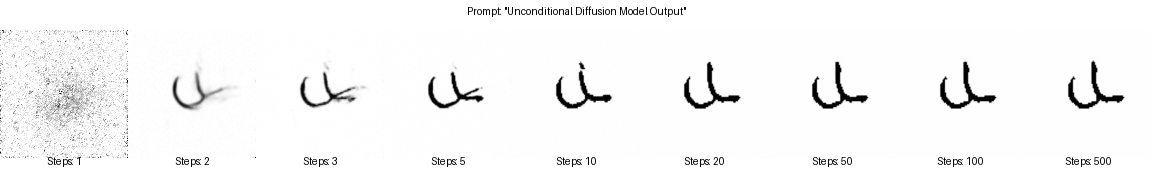

In [ ]:
from diffusers import DPMSolverMultistepScheduler, DDPMPipeline
from PIL import Image, ImageDraw, ImageFont
import torch

def make_labeled_grid(images, prompt, steps, font_path=None, font_size=20, margin=10):
    assert len(images) == len(steps), "The number of images must match the number of steps"

    w, h = images[0].size
    font = ImageFont.truetype(font_path, font_size) if font_path else ImageFont.load_default()

    # Calculate the height of the grid including the margin for text
    total_height = h + margin + font_size
    total_width = w * len(images)
    grid_height = total_height + margin + font_size  # Add extra margin for the prompt
    grid = Image.new('RGB', size=(total_width, grid_height), color=(255, 255, 255))
    # Draw the text prompt at the top
    draw = ImageDraw.Draw(grid)
    prompt_text = f"Prompt: \"{prompt}\""
    prompt_width, prompt_height = draw.textbbox((0, 0), prompt_text, font=font)[2:4]
    prompt_x = (total_width - prompt_width) / 2
    prompt_y = margin / 2
    draw.text((prompt_x, prompt_y), prompt_text, fill="black", font=font)

    for i, (image, step) in enumerate(zip(images, steps)):
        # Calculate position to paste the image
        x = i * w
        y = margin + font_size

        # Paste the image
        grid.paste(image, box=(x, y))

        # Draw the step text
        step_text = f"Steps: {step}"
        text_width, text_height = draw.textbbox((0, 0), step_text, font=font)[2:4]
        text_x = x + (w - text_width) / 2
        text_y = y + h + margin / 2 - 8
        draw.text((text_x, text_y), step_text, fill="black", font=font)
    return grid

# Initialize the model pipeline using your local model
# model_path = "/content/drive/MyDrive/AI_Diffusion_Arabic/diffusion-arabic-ocr-and-synthetic-combined-lighter/epoch19"  # Path to your trained model
pipeline = DDPMPipeline.from_pretrained(model_path).to("cuda")
pipeline.scheduler = DPMSolverMultistepScheduler()

# Define the number of steps to visualize
num_inference_steps_list = [1, 2, 3, 5, 10, 20, 50,100,500]

images = []

# Generate images for each value in num_inference_steps_list
for num_steps in num_inference_steps_list:
    generated_images = pipeline(
        batch_size=1,
        generator=torch.Generator(device='cuda').manual_seed(0),
        num_inference_steps=num_steps
    ).images
    images.append(generated_images[0])  # Append the generated image

# Create the labeled grid with a descriptive prompt since this is an unconditional model
prompt = "Unconditional Diffusion Model Output"
image_grid = make_labeled_grid(images, prompt, num_inference_steps_list)

# Show the grid
from IPython.display import display
display(image_grid)

# Save the image grid
image_grid.save(f"{model_path}epoch19_diffusion_steps_visualization3.png")

### Step 14: Create animated visualization

In [ ]:
from collections import Counter
from pathlib import Path

root = Path("data")        # after you merged PNG + OCR
counter = Counter()

for p in root.rglob("*.png", "*.jpg"):
    print(p)
    # file names like Amiri-Regular_U+0621.png
    code_hex = p.stem.split("_")[-1]          # yields "U+0621"
    counter[code_hex] += 1

print("Top 10 most frequent:")
for code, n in counter.most_common(10):
    print(code, n)

In [ ]:
from diffusers import DPMSolverMultistepScheduler, DDPMPipeline
from PIL import Image, ImageDraw, ImageFont
import torch
import numpy as np
import os
import imageio.v2 as imageio
from tqdm import tqdm

# Initialize the model pipeline using your local model
model_path = "content/drive/MyDrive/AI_Diffusion_Arabic/diffusion-arabic-ocr-and-synthetic-combined/epoch19"  # Path to your trained model
# model_path = "/content/drive/MyDrive/AI_Diffusion_Arabic/diffusion-arabic-ocr-and-synthetic-combined-lighter/epoch19"
# https://colab.research.google.com/drive/13Oa2vUWfEiGe0r6_WYO56vG2pBp-8AqW#scrollTo=pGa7pruCUaTV
pipeline = DDPMPipeline.from_pretrained(model_path).to("cuda")
pipeline.scheduler = DPMSolverMultistepScheduler()

# Create output directory for frames
os.makedirs("animation_frames", exist_ok=True)

# Set parameters
num_inference_steps = 50
seed = 42

# Use the model's forward process to generate images at each step
print("Generating denoising frames...")

# Start with pure noise (t=1000)
generator = torch.Generator(device="cuda").manual_seed(seed)

# Store all frames
frames = []

# The correct way to visualize the denoising process is to use the pipeline with
# increasing numbers of denoising steps
for step in tqdm(range(0, num_inference_steps + 1, 2)):  # Skip some steps for faster generation
    if step == 0:
        # For the initial noise, just use the pipeline with 1 step
        # This will effectively show the noise
        current_step = 1
    else:
        current_step = step

    # Generate the image with the current number of denoising steps
    image = pipeline(
        batch_size=1,
        generator=torch.Generator(device="cuda").manual_seed(seed),
        num_inference_steps=current_step
    ).images[0]

    # Save the frame
    image.save(os.path.join("animation_frames", f"frame_{step:03d}.png"))
    frames.append(image)

# Create GIF from frames
print("Creating GIF animation...")
# Ensure all frames have the same size (shouldn't be necessary but just in case)
frames_resized = [frame.resize((256, 256)) for frame in frames]

# Save as GIF
output_gif = f"{model_path}_diffusion_process.gif"
frames_resized[0].save(
    output_gif,
    save_all=True,
    append_images=frames_resized[1:],
    optimize=False,
    duration=150,  # milliseconds per frame - slower to see the changes
    loop=0  # 0 means loop indefinitely
)

print(f"Animation saved to {output_gif}")

# Create a grid showing selected frames
def create_process_grid(frames, num_to_show=8):
    # Select frames evenly throughout the process
    if len(frames) <= num_to_show:
        selected_frames = frames
    else:
        indices = np.linspace(0, len(frames)-1, num_to_show, dtype=int)
        selected_frames = [frames[i] for i in indices]

    # Resize frames
    width, height = 256, 256
    selected_frames = [frame.resize((width, height)) for frame in selected_frames]

    # Create grid image
    cols = min(4, num_to_show)
    rows = (num_to_show + cols - 1) // cols

    grid = Image.new('RGB', (width * cols, height * rows))

    for i, frame in enumerate(selected_frames):
        row = i // cols
        col = i % cols
        grid.paste(frame, (col * width, row * height))

    return grid

# Create and save the grid
grid = create_process_grid(frames)
grid.save(f"{model_path}_lighter_combined_diffusion_process_grid3.png")
print(f"Process grid saved to {model_path}_lighter_combined_diffusion_process_grid3.png")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Generating denoising frames...



  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/48 [00:00<?, ?it/s]


 96%|█████████▌| 25/26 [00:10<00:00,  1.30it/s]

  0%|          | 0/50 [00:00<?, ?it/s]


100%|██████████| 26/26 [00:11<00:00,  2.20it/s]

Creating GIF animation...
Animation saved to /content/drive/MyDrive/AI_Diffusion_Arabic/diffusion-arabic-ocr-and-synthetic-combined-lighter/epoch19_diffusion_process.gif
Process grid saved to /content/drive/MyDrive/AI_Diffusion_Arabic/diffusion-arabic-ocr-and-synthetic-combined-lighter/epoch19_lighter_combined_diffusion_process_grid3.png


###Step 15: Download your contents locally!

In [ ]:
from pathlib import Path
import shutil
from google.colab import drive

# 2) Define source and destination paths
SRC_DIR     = Path('content')
ARCHIVE_BASE = Path('content/content_archive')        # base name (no extension)
ARCHIVE_ZIP  = ARCHIVE_BASE.with_suffix('.zip')        # /content/content_archive.zip
DRIVE_DST    = Path('content/drive/My Drive/content_archive.zip')

# 3) Create a fresh ZIP of SRC_DIR
if ARCHIVE_ZIP.exists():
    ARCHIVE_ZIP.unlink()
print(f"Zipping {SRC_DIR} → {ARCHIVE_ZIP}…")
shutil.make_archive(
    base_name=str(ARCHIVE_BASE),   # do not include “.zip” here
    format='zip',
    root_dir=str(SRC_DIR)          # folder to compress
)

# 4) Verify and copy into Drive
if not ARCHIVE_ZIP.exists():
    raise FileNotFoundError(f"Failed to create archive: {ARCHIVE_ZIP}")
DRIVE_DST.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(str(ARCHIVE_ZIP), str(DRIVE_DST))

print(f"✅ Archive saved to Drive at: {DRIVE_DST}")

Zipping content → content/content_archive.zip…
✅ Archive saved to Drive at: content/drive/My Drive/content_archive.zip
